# Regressione Probabilistica tramite Processi Gaussiani (GPR)

In questa fase del progetto, l'obiettivo è modellare il **comportamento nominale** del motore aeronautico per definire un riferimento di "salute" della flotta.
È stata utilizzata la **Regressione tramite Processi Gaussiani (GPR)** per stimare la coppia target ($Trq_{target}$) in base alle condizioni operative.

Il valore aggiunto di questo approccio è la capacità di fornire non solo una stima puntuale, ma una **distribuzione di probabilità** che permette di calcolare il **Torque Margin** e la relativa incertezza.

Lo scoring finale segue le specifiche ufficiali **PHM 2024 Data Challenge**: per ogni osservazione del validation set viene costruita una PDF gaussiana del torque margin (tramite campionamento Monte Carlo dal GPR) e valutata secondo la funzione `get_regression_score` ufficiale.

In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Import delle librerie
Importazione di tutte le dipendenze necessarie, inclusa la funzione di scoring ufficiale PHM (`get_regression_score`) e quella per il punteggio finale (`get_challange_score`).

In [15]:
import os
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path
from scipy.integrate import simpson

current_dir = Path.cwd()
while not (current_dir / "src").exists() and current_dir != current_dir.parent:
    current_dir = current_dir.parent
SRC_DIR = current_dir / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dataset import load_dataset
from regression.GPR.gpr_model import GPRModel
from regression.GPR.gpr_sampling import lhs_nearest_sampling
from regression.probabilistic_rf_scoring import plot_pdf_with_true_target
from score_PHM import get_regression_score, get_challange_score

plt.style.use("default")
from plot_style import set_plot_style
set_plot_style()

## 2. Configurazione percorsi e costanti
Definizione dei percorsi ai file del dataset, del modello salvato e dell'output. `MODEL_FILE` punta al modello GPR addestrato su 500 campioni LHS.

In [16]:
ROOT_DIR = Path(os.getcwd()).parents[3]
SRC_PATH = ROOT_DIR / "src"
DATA_PATH = ROOT_DIR / "data" / "processed"
OUTPUT_PATH = ROOT_DIR / "output" / "GPR" / "model_target"
TRAIN_PATH_SPLIT = "../../../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT  = "../../../../data/processed/split_85_15/test_15.csv"
MODEL_FILE  = OUTPUT_PATH / "gpr_model_500.pkl"
SCALER_FILE = OUTPUT_PATH / "scaler_gpr.pkl"
OUTPUT_CSV  = OUTPUT_PATH / "test_with_features_enriched.csv"

if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

## 3. Definizione features e target
Le features operative utilizzate come input del GPR sono: torque misurato, temperatura gas motore, velocità indicata, temperatura esterna, rapporto Np/Ng e pressione altimetrica. Il target è il torque nominale di progetto (`trq_target`).

In [18]:
FEATURES    = ["trq_measured", "mgt", "ias", "oat", "np_ng_ratio", "pa"]
TARGET_NAME = "trq_target"

## 4. Caricamento del dataset
Caricamento del training set (85%) e del test set (15%) dal split pre-processato.

In [19]:
train_df = load_dataset(TRAIN_PATH_SPLIT)
test_df  = load_dataset(TEST_PATH_SPLIT)

## 5. Addestramento o caricamento del modello GPR
Se il modello è già stato addestrato e salvato su disco, viene caricato direttamente. In caso contrario, si esegue il campionamento LHS sul training set, si normalizzano le features tramite scaler e si addestra il GPR. Il modello e lo scaler vengono poi salvati per usi futuri.

In [20]:
gpr_model = GPRModel(random_state=42)

if MODEL_FILE.exists() and SCALER_FILE.exists():
    print("Modello pre-addestrato trovato! Caricamento in corso...")
    try:
        gpr_model = joblib.load(MODEL_FILE)
        scaler    = joblib.load(SCALER_FILE)
        print("SUCCESSO: Modello e Scaler caricati correttamente.")
        addestramento_necessario = False
    except Exception as e:
        print(f"Errore nel caricamento dei file: {e}")
        addestramento_necessario = True
else:
    print("Modello non trovato o incompleto. Avvio procedura di addestramento...")
    addestramento_necessario = True

if addestramento_necessario:
    # Campionamento LHS e normalizzazione
    X_train_scaled, y_train, scaler = lhs_nearest_sampling(
        train_df, FEATURES, TARGET_NAME, n_samples=5000
    )
    print("Addestramento GPR in corso...")
    gpr_model.fit(X_train_scaled, y_train)

    OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
    try:
        joblib.dump(gpr_model, MODEL_FILE)
        joblib.dump(scaler,    SCALER_FILE)
        print(f"SUCCESSO: Modello salvato in -> {MODEL_FILE}")
        print(f"SUCCESSO: Scaler salvato in  -> {SCALER_FILE}")
    except Exception as e:
        print(f"ERRORE DURANTE IL SALVATAGGIO: {e}")

Modello pre-addestrato trovato! Caricamento in corso...
SUCCESSO: Modello e Scaler caricati correttamente.


## 6. Trasformazione del test set
Le features del test set vengono normalizzate con lo stesso scaler usato in fase di training, per garantire coerenza con lo spazio di input del modello.

In [21]:
test_X = scaler.transform(test_df[FEATURES])
test_y = test_df[TARGET_NAME]

## 7. Valutazione del modello (metriche standard)
Calcolo delle metriche tradizionali di regressione (MAE, RMSE, R²) sul test set per verificare la qualità della predizione puntuale del GPR sul `trq_target`.

In [22]:
gpr_model.evaluate(test_X, test_y)

{'rmse': 0.034370593535285654,
 'mae': 0.012882414897329409,
 'r2': 0.9999941618428474}

## 8. Analisi probabilistica su un singolo volo (esplorazione)
Per un singolo volo di esempio (idx=100), si mostra la distribuzione del torque margin ottenuta tramite il metodo delta (propagazione analitica dell'incertezza del GPR). Questa cella è utile per ispezionare visivamente la qualità della predizione probabilistica prima di applicarla all'intero dataset.

--- Analisi Volo ID: 100 ---
Margin Vero:     -6.0470
Margin Predetto: -6.0477
Incertezza (std): 0.0781


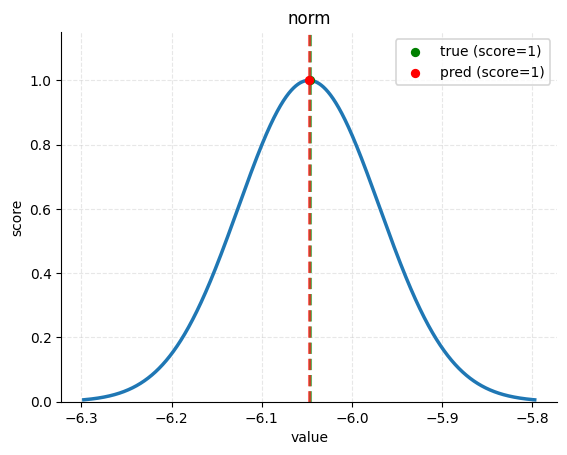

{'pdf_type': 'norm',
 'true_target': -6.047048375117548,
 'prediction': -6.0477458122564105,
 'score_true': 0.9999601235681878,
 'score_pred': 1.0000000050001,
 'x_range': (-6.297397093686979, -5.797397093686979)}

In [23]:
idx       = 100
flight_id = test_df.iloc[idx]['id'] if 'id' in test_df.columns else idx
row_X     = test_X[idx:idx+1]

# Predizione GPR: media e deviazione standard del trq_target
mu, std = gpr_model.predict(row_X, return_std=True)
mu_target  = float(mu[0])
std_target = float(std[0])

# Valori reali
trq_measured_real = float(test_df.iloc[idx]['trq_measured'])
trq_target_true   = float(test_y.iloc[idx])

# Torque margin reale e predetto
trq_margin_true     = 100 * (trq_measured_real / trq_target_true - 1)
trq_margin_predetto = 100 * (trq_measured_real / mu_target - 1)

# Propagazione dell'incertezza con metodo delta: std_margin = |dM/dTrq_target| * std_target
std_margin = np.abs(-100 * trq_measured_real / (mu_target**2)) * std_target

print(f"--- Analisi Volo ID: {int(flight_id)} ---")
print(f"Margin Vero:     {trq_margin_true:.4f}")
print(f"Margin Predetto: {trq_margin_predetto:.4f}")
print(f"Incertezza (std): {std_margin:.4f}")

# Visualizzazione della PDF gaussiana con il valore reale indicato
pdf_args = {"loc": trq_margin_predetto, "scale": std_margin}
plot_pdf_with_true_target("norm", pdf_args=pdf_args, true_target=trq_margin_true, y_pred=trq_margin_predetto)

## 9. Analisi Monte Carlo su un singolo volo (esplorazione)
Alternativa al metodo delta: si campionano 5000 predizioni dal GPR e si ricava empiricamente la distribuzione del torque margin. Permette di catturare eventuali asimmetrie non lineari nella trasformazione del margine.

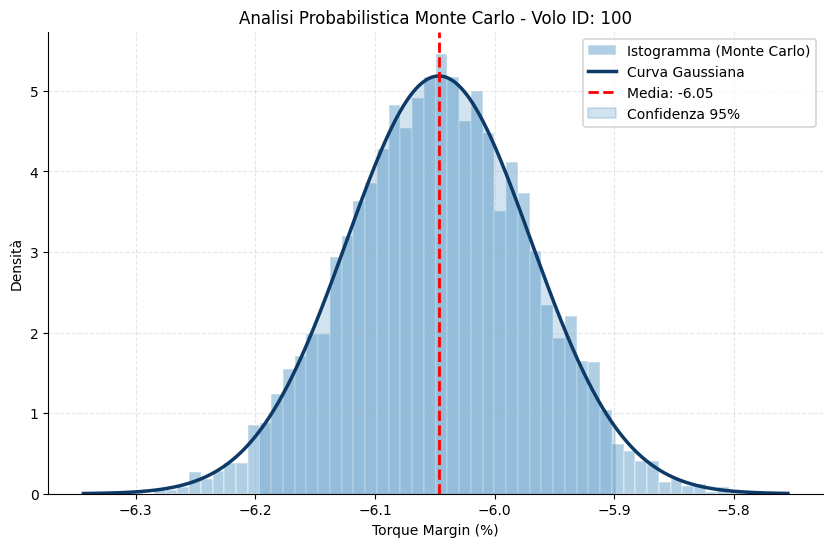

,Parametro,Valore
0,ID Volo,100
1,Media Margine (μ),-6.0465
2,Varianza (σ²),0.005921
3,Deviazione Standard (σ),0.0769
4,Intervallo Confidenza (95%),"[-6.20 , -5.90]"


In [24]:
idx             = 100
flight_id       = test_df.iloc[idx]['id'] if 'id' in test_df.columns else idx
test_row        = test_X[idx:idx+1]
trq_measured_real = float(test_df.iloc[idx]['trq_measured'])

# Campionamento Monte Carlo dal GPR
y_trq_samples  = gpr_model.sample_y(test_row, n_sample=5000).flatten()
margin_samples = 100 * (trq_measured_real / y_trq_samples - 1)

# Statistiche empiriche
mu_mc    = np.mean(margin_samples)
var_mc   = np.var(margin_samples)
std_mc   = np.std(margin_samples)
ci_lower = np.percentile(margin_samples, 2.5)
ci_upper = np.percentile(margin_samples, 97.5)

# Grafico distribuzione
x_range = np.linspace(np.min(margin_samples), np.max(margin_samples), 1000)
plt.figure(figsize=(10, 6))
plt.hist(margin_samples, bins=60, density=True, alpha=0.35, color='#1f77b4',
         edgecolor='white', label='Istogramma (Monte Carlo)')
y_pdf = stats.norm.pdf(x_range, mu_mc, std_mc)
plt.plot(x_range, y_pdf, color='#0d3a66', lw=2.5, label='Curva Gaussiana')
plt.axvline(mu_mc, color='red', linestyle='--', lw=2, label=f'Media: {mu_mc:.2f}')
plt.fill_between(x_range, y_pdf,
                 where=(x_range >= ci_lower) & (x_range <= ci_upper),
                 color='#1f77b4', alpha=0.2, label='Confidenza 95%')
plt.title(f'Analisi Probabilistica Monte Carlo - Volo ID: {int(flight_id)}')
plt.xlabel('Torque Margin (%)')
plt.ylabel('Densità')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Tabella riassuntiva
display(pd.DataFrame({
    "Parametro": ["ID Volo", "Media Margine (μ)", "Varianza (σ²)", "Deviazione Standard (σ)", "Intervallo Confidenza (95%)"],
    "Valore":    [int(flight_id), f"{mu_mc:.4f}", f"{var_mc:.6f}", f"{std_mc:.4f}", f"[{ci_lower:.2f} , {ci_upper:.2f}]"]
}))

## 10. Calcolo PHM Regression Score sull'intero test set

Questa è la parte **richiesta dalla competizione PHM 2024**.

Per ogni osservazione del test set:
1. Si campionano 5000 valori di `trq_target` dal GPR (Monte Carlo)
2. Si trasformano in `trq_margin` usando la formula fisica: `100 * (trq_measured / trq_target - 1)`
3. Si stima una PDF gaussiana (`norm`) con media e std dei campioni
4. Si calcola il **PHM regression score** ufficiale: `pdf(true_margin)` normalizzato su `[-100, 100]`

Il risultato è la media degli score su tutto il test set.

In [11]:
scores      = []
predictions = []  # lista per la submission JSON

for idx in range(len(test_df)):
    row_X             = test_X[idx:idx+1]
    trq_measured_real = float(test_df.iloc[idx]['trq_measured'])
    true_margin       = float(test_df.iloc[idx]['trq_margin'])

    # Campionamento Monte Carlo dal GPR sul trq_target
    y_samples      = gpr_model.sample_y(row_X, n_sample=5000).flatten()
    margin_samples = 100 * (trq_measured_real / y_samples - 1)

    # Parametri della PDF gaussiana del margin
    mu_margin  = float(np.mean(margin_samples))
    std_margin = float(np.std(margin_samples))

    pdf_args = {"loc": mu_margin, "scale": std_margin}

    # PHM regression score ufficiale
    s = get_regression_score("norm", pdf_args, true_margin)
    scores.append(s)

    # Salvo i dati per la submission
    predictions.append({
        "pdf_type": "norm",
        "pdf_args": pdf_args
    })

phm_regression_score = float(np.mean(scores))
print(f"PHM Regression Score medio (test set): {phm_regression_score:.6f}")
print(f"Score min: {min(scores):.6f}  |  Score max: {max(scores):.6f}")

PHM Regression Score medio (test set): 0.945604
Score min: 0.000000  |  Score max: 1.000000


## 11. Salvataggio del margin predetto per il classificatore
Il GPR predice , da cui si ricava il torque margin predetto con la formula fisica.
La media dei campioni Monte Carlo viene usata come stima puntuale del margin per ogni campione.
Il risultato viene salvato in , che il notebook del classificatore userà come feature di input.

In [25]:
# Salva il margin predetto dal GPR per il classificatore
pred_margin_df = test_df[["oat", "pa", "np_ng_ratio", "ias", "mgt", "faulty", "trq_measured"]].copy()

trq_target_preds = []
for i in range(len(test_df)):
    y_samples = gpr_model.sample_y(test_X[i:i+1], n_sample=500).flatten()
    trq_target_preds.append(float(np.mean(y_samples)))  # stima puntuale: media campioni

# Calcolo margin dalla formula fisica: 100 * (trq_measured / trq_target_pred - 1)
pred_margin_df["trq_margin_pred"] = 100 * (pred_margin_df["trq_measured"] / np.array(trq_target_preds) - 1)
pred_margin_df = pred_margin_df.drop(columns=["trq_measured"])

pred_margin_df.to_csv(OUTPUT_PATH / "pred_margin_test.csv", index=False)
print(f"Salvato pred_margin_test.csv con {len(pred_margin_df)} campioni")
print(pred_margin_df[["trq_margin_pred", "faulty"]].head())

Salvato pred_margin_test.csv con 111394 campioni
   trq_margin_pred  faulty
0        12.614026       0
1         2.422372       0
2        -7.048203       1
3         6.948820       0
4        -0.909639       0


## 11. Distribuzione degli score sul test set
Visualizzazione della distribuzione dei PHM regression score su tutti i campioni del test set, utile per identificare eventuali osservazioni su cui il modello performa peggio.

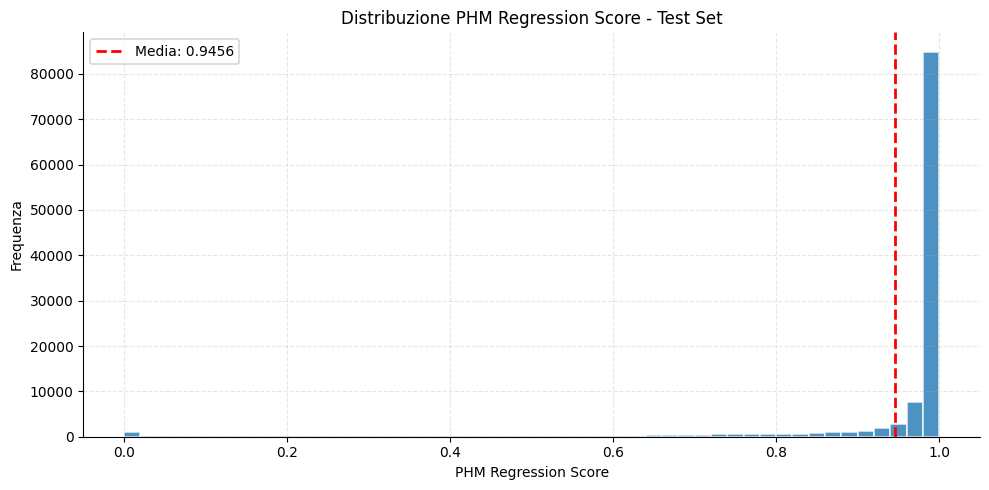

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(scores, bins=50, color='#1f77b4', edgecolor='white', alpha=0.8)
plt.axvline(phm_regression_score, color='red', linestyle='--', lw=2,
            label=f'Media: {phm_regression_score:.4f}')
plt.title('Distribuzione PHM Regression Score - Test Set')
plt.xlabel('PHM Regression Score')
plt.ylabel('Frequenza')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Generazione file di submission JSON
Creazione del file di submission nel formato richiesto da PHM 2024. Per ogni campione (indicizzato da 0) viene salvato il tipo di PDF e i suoi parametri. Il campo `class` e `class_conf` dovranno essere completati con i risultati del modello di classificazione.

>  **Nota**: PHM richiede l'estensione `.jso` (non `.json`) per il file di submission.

In [13]:
# Salva JSON parziale con solo regressione
submission_partial = {}
for i, pred in enumerate(predictions):
    submission_partial[str(i)] = {
        "pdf_type": pred["pdf_type"],
        "pdf_args": pred["pdf_args"]
    }

with open(OUTPUT_PATH / "submission_partial.json", "w") as f:
    json.dump(submission_partial, f, indent=4)